# Simple CNN using keras

## import libraries

In [1]:
import enum
import json
from numpy.random import shuffle
import tensorflow  as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import callbacks, layers, metrics, optimizers

I0000 00:00:1775216637.348028  556360 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775216637.348362  556360 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775216637.384651  556360 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1775216638.929000  556360 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775216638.929229  556360 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## loading mnist

In [2]:
def print_data_info(x_train, y_train, x_test, y_test):
    for name, data in zip(['x_train','y_train','x_test','y_test'],
                          [x_train, y_train, x_test, y_test]):
        print(name, type(data), data.shape, data.dtype)

# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print_data_info(x_train, y_train, x_test, y_test);

x_train <class 'numpy.ndarray'> (60000, 28, 28) uint8
y_train <class 'numpy.ndarray'> (60000,) uint8
x_test <class 'numpy.ndarray'> (10000, 28, 28) uint8
y_test <class 'numpy.ndarray'> (10000,) uint8


## reshaping and type conversion

In [3]:
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)

print_data_info(x_train, y_train, x_test, y_test);

x_train <class 'numpy.ndarray'> (60000, 28, 28, 1) float32
y_train <class 'numpy.ndarray'> (60000,) uint8
x_test <class 'numpy.ndarray'> (10000, 28, 28, 1) float32
y_test <class 'numpy.ndarray'> (10000,) uint8


## building sequential model

In [4]:
input_shape=(28, 28, 1)
model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # feed into FCNN
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"), # 10 classes
])

E0000 00:00:1775216640.163789  556360 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775216640.164119  556436 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775216640.186211  556360 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## model summary

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## compile the model

In [6]:
model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

## train the model

In [7]:
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=0
)

## evaluate the model

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

Test accuracy: 0.9908
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


# Exercise

## Task 1: Data Understanding and Visualization

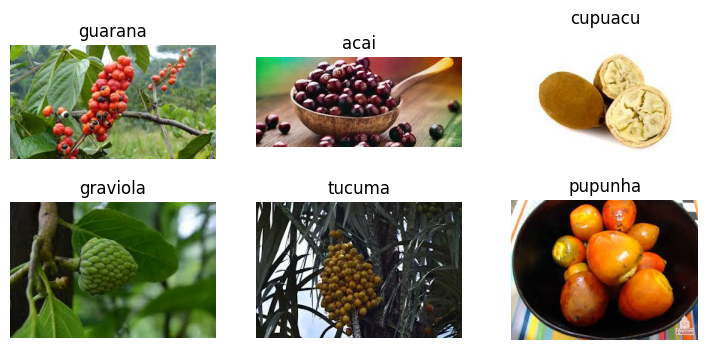

In [9]:
import os
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-5/dataset/train/"
test_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-5/dataset/test/"

# Get the list of class directories from the train folder.
dirs = os.listdir(train_dir)

select_img_paths = []
# Select one image randomly from each class.
for dir in dirs: 
    images =  os.listdir(os.path.join(train_dir, dir))
    random_idx = np.random.randint(0, len(images))

    img_path = os.path.join(train_dir, dir, images[random_idx])
    select_img_paths.append(img_path)

# Display the images in a grid format with two rows using matplotlib.
plt.figure(figsize=(9, 4))
for i, img_path in enumerate(select_img_paths):
    plt.subplot(2, 3, i + 1) 
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.split("/")[-2])

### check for corrupted images

In [10]:
def check_corrupted_images(dir):
    dirs = os.listdir(dir)
    images, corrupted_images = [], []
    for dir_path in dirs: 
        img_paths = os.listdir(os.path.join(dir, dir_path));
        for img in img_paths:
            img_path = os.path.join(dir, dir_path, img)
            try: 
                Image.open(img_path)
                images.append(img_path)
            except Exception as e:
                print(f"Error while opening image {img_path}", e)
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image {img_path}", e)

    return images, corrupted_images;

images, corrupted_images = check_corrupted_images(train_dir)
if(len(corrupted_images) == 0):
    print(f"No corrupted images found in train dir")

images, corrupted_images = check_corrupted_images(test_dir)
if(len(corrupted_images) == 0):
    print(f"No corrupted images found test_dir")

No corrupted images found in train dir
No corrupted images found test_dir


## Task 2: Loading and Preprocessing Image Data in keras

In [11]:
import tensorflow as tf

# conts values
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2

# Preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # normalize to [0, 1]

# creating training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels = "inferred",
    label_mode = "int",
    image_size = (img_height, img_width),
    interpolation = "nearest",
    batch_size = batch_size,
    shuffle =True,
    validation_split=validation_split,
    subset="training",
    seed=42
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-5/dataset/test/"

# creating validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels = "inferred",
    label_mode = "int",
    image_size = (img_height, img_width),
    interpolation = "nearest",
    batch_size = batch_size,
    shuffle = True,
    validation_split=validation_split,
    subset="validation",
    seed=42
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.


Using 72 files for training.


Found 90 files belonging to 6 classes.


Using 18 files for validation.


## Task3: implementing CNN

In [12]:
tf.keras.backend.clear_session()  # resets all layer counters
input_shape = (128, 128, 3)

model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), 1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    layers.Conv2D(32, (3, 3), 1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # FCNN
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(6, activation="softmax"), # 6 classes
])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

None


## Model Compilation

In [13]:
model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

## Task 4: Train the model

### model training

In [14]:
import json

# make sure 
os.makedirs("./model_checkpoints", exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="./model_checkpoints/model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4)
]

history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=0
)

print(history.history.keys())
print(json.dumps(history.history, indent=2))

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
{
  "accuracy": [
    0.0972222238779068,
    0.4861111044883728,
    0.4444444477558136,
    0.4722222089767456,
    0.625,
    0.75,
    0.8055555820465088,
    0.8055555820465088,
    0.8611111044883728,
    0.9027777910232544,
    0.9027777910232544,
    0.9722222089767456
  ],
  "loss": [
    1.8757951259613037,
    1.7017035484313965,
    1.4229607582092285,
    1.314669132232666,
    1.0740399360656738,
    0.9960456490516663,
    0.8421168923377991,
    0.69138103723526,
    0.532866358757019,
    0.41320356726646423,
    0.3266373574733734,
    0.2106851041316986
  ],
  "val_accuracy": [
    0.2777777910232544,
    0.1666666716337204,
    0.3333333432674408,
    0.1666666716337204,
    0.3333333432674408,
    0.5,
    0.3888888955116272,
    0.3888888955116272,
    0.4444444477558136,
    0.3333333432674408,
    0.5,
    0.3888888955116272
  ],
  "val_loss": [
    1.9326798915863037,
    1.7665420770645142,
    1.6896

## Task 5: Model Evaluation

In [36]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels = "inferred",
    label_mode = "int",
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = False,
    seed=42
)

class_names = test_ds.class_names 
test_ds = test_ds.map(lambda x, y: (rescale(x), y))  

loss, accuracy = model.evaluate(
    test_ds,
    batch_size=batch_size,
    verbose=0
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Found 30 files belonging to 6 classes.


Test Loss: 1.1758
Test Accuracy: 0.6000


## Task 6: Save and Load the Model

In [35]:
model.save('image_classifier_cnn.h5')
loaded_model = tf.keras.models.load_model('image_classifier_cnn.h5')

## Task 7: Predictions and Classification Report

In [34]:
# predict on test data
predictions = loaded_model.predict(test_ds, verbose=0)

# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
y_labels = np.concatenate([y for x, y in test_ds], axis=0)

# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {y_labels[0]}")

Predicted label for first image: 0
True label for first image: 0


### clasification report

In [32]:
from sklearn.metrics import classification_report

true_labels = []
predicted_labels = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(preds, axis=1))
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# pass class names here ↓
report = classification_report(true_labels, predicted_labels, target_names=class_names, zero_division=0)
print(report)

              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       0.80      0.80      0.80         5
    graviola       0.75      0.60      0.67         5
     guarana       0.44      0.80      0.57         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.60        30
   macro avg       0.52      0.60      0.54        30
weighted avg       0.52      0.60      0.54        30



### visualization

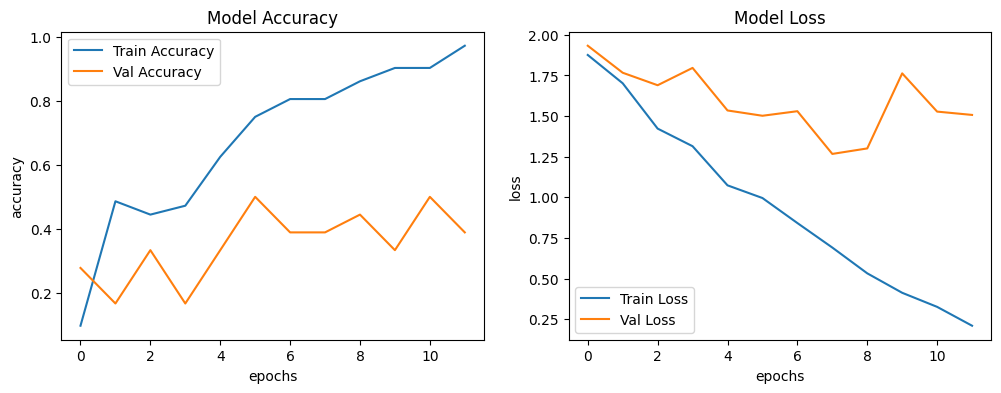

In [33]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()